# 1.6.Plot variance parititoning results
This notebook:
1. Reads in results obtained from 1.5.
2. Visualizes the full ANOVA eta2 division among covariates across all metric, degradation combinations.
3. Visualizes a more condensed eta2 division grouping covariates by degradation, confounders and residual for a more intuitive presentation.
4. Writies plots to disks.

In [1]:
from pathlib import Path

import pandas as pd

from utils.validate_config import load_degradation_plot_config
from utils.var_partition_plot import plot_anova_variance_partition
from utils.var_partition_radar import (
    plot_anova_radar,
    plot_anova_radar_by_degradation,
)

In [2]:
anova_output_dir = Path(".") / "results" / "variance_partition_analysis"
if not anova_output_dir.exists():
    raise FileNotFoundError(
        f"ANOVA output directory {anova_output_dir} does not exist. "
        f"Please run 1.5.variance_parition_analysis.ipynb first."
    )

anova_results_file = anova_output_dir / "variance_partition_results.parquet"
if not anova_results_file.exists():
    raise FileNotFoundError(
        f"ANOVA results file {anova_results_file} does not exist. "
        f"Please run 1.5.variance_parition_analysis.ipynb first."
    )

variance_partition_df = pd.read_parquet(anova_results_file)

plot_dir = anova_output_dir / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

In [3]:
degradation_plot_config = load_degradation_plot_config("degradation_plot_config.yaml")

METRIC_ORDER = degradation_plot_config["metrics"]["order"]
METRIC_LABELS = degradation_plot_config["metrics"]["labels"]
METRIC_PALETTE = degradation_plot_config["metrics"]["palette"]
TRANSFORM_ORDER = degradation_plot_config["transforms"]["order"]
TRANSFORM_LABELS = degradation_plot_config["transforms"]["labels"]

TERM_COLORS = {
    "parameter_value": "#E69F00",
    "cell_line": "#0072B2",
    "seeding_density": "#009E73",
    "channel": "#6A3D9A",
    "cell_line:seeding_density": "#8DA0CB",
    "cell_line:channel": "#66C2A5",
    "seeding_density:channel": "#B2ABD2",
    "parameter_value:cell_line": "#D55E00",
    "parameter_value:seeding_density": "#CC79A7",
    "parameter_value:channel": "#A6761D",
    "Residual": "#9E9E9E",
}

TERM_ORDER = [
    "parameter_value",
    "cell_line",
    "seeding_density",
    "channel",
    "cell_line:seeding_density",
    "cell_line:channel",
    "seeding_density:channel",
    "parameter_value:seeding_density",
    "parameter_value:cell_line",
    "parameter_value:channel",
    "Residual",
]

TERM_LABELS = {
    "parameter_value": "Severity",
    "cell_line": "Cell line",
    "seeding_density": "Seeding density",
    "channel": "Channel",
    "cell_line:seeding_density": "Cell line x Seeding density",
    "cell_line:channel": "Cell line x Channel",
    "seeding_density:channel": "Seeding density x Channel",
    "parameter_value:cell_line": "Severity x Cell line",
    "parameter_value:seeding_density": "Severity x Seeding density",
    "parameter_value:channel": "Severity x Channel",
    "Residual": "Residual",
}

In [4]:
HATCH_GROUPS = {
    "Univariate known": (
        {
            "cell_line",
            "seeding_density",
            "channel",
        },
        "//",
    ),
    "Interaction terms": (
        {
            "cell_line:seeding_density",
            "cell_line:channel",
            "seeding_density:channel",
            "parameter_value:seeding_density",
            "parameter_value:cell_line",
            "parameter_value:channel",
        },
        "..",
    ),
}

Saved figure to results/variance_partition_analysis/plots/anova_metric_color.png


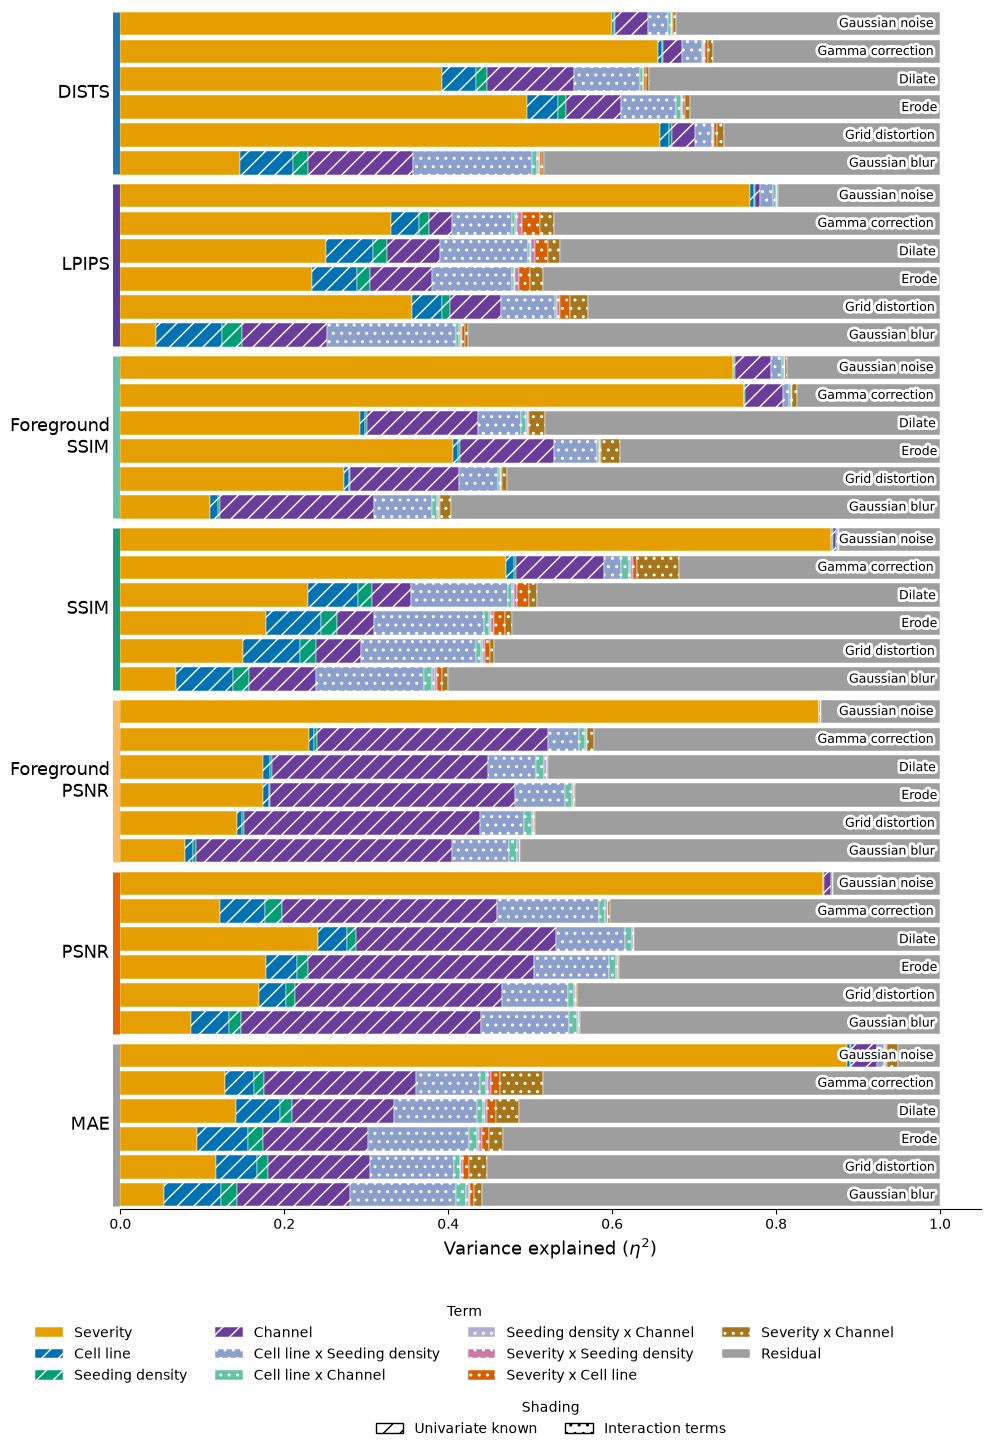

In [5]:
fig, ax, plot_wide = plot_anova_variance_partition(
    variance_partition_df,
    row_cols=(
        "metric_name",
        "transform_name",
    ),
    value_col="eta2",
    term_labels=TERM_LABELS,
    term_order=TERM_ORDER,
    term_colors=TERM_COLORS,
    hatch_groups=HATCH_GROUPS,
    row_orders={
        "metric_name": METRIC_ORDER,
        "transform_name": TRANSFORM_ORDER,
    },
    row_value_labels={
        "metric_name": {
            **METRIC_LABELS,
            "foreground_ssim": "Foreground\nSSIM",
            "foreground_psnr": "Foreground\nPSNR",
        },
        "transform_name": {k: v.replace("\n", " ") for k, v in TRANSFORM_LABELS.items()},
    },
    row_group_col="metric_name",
    row_group_colors=METRIC_PALETTE,
    row_group_label_x=-0.0125,
    row_group_line_x=-0.005,
    row_group_label_fontsize=13,
    row_group_label_fontweight=None,
    row_group_linewidth=5,
    row_group_line_gap=0.05,
    row_group_gap=0.18,
    row_labels_side="inside",
    row_label_x=0.95,
    row_label_color="black",
    row_label_fontsize=9,
    row_label_outline_width=4,
    show_y_axis=False,
    xlabel_fontsize=13,
    ylabel="",
    output_path=plot_dir / "anova_metric_color.png",
    figsize_width=10,
    row_height=0.34,
    show=True,
)

Saved figure to results/variance_partition_analysis/plots/anova.png


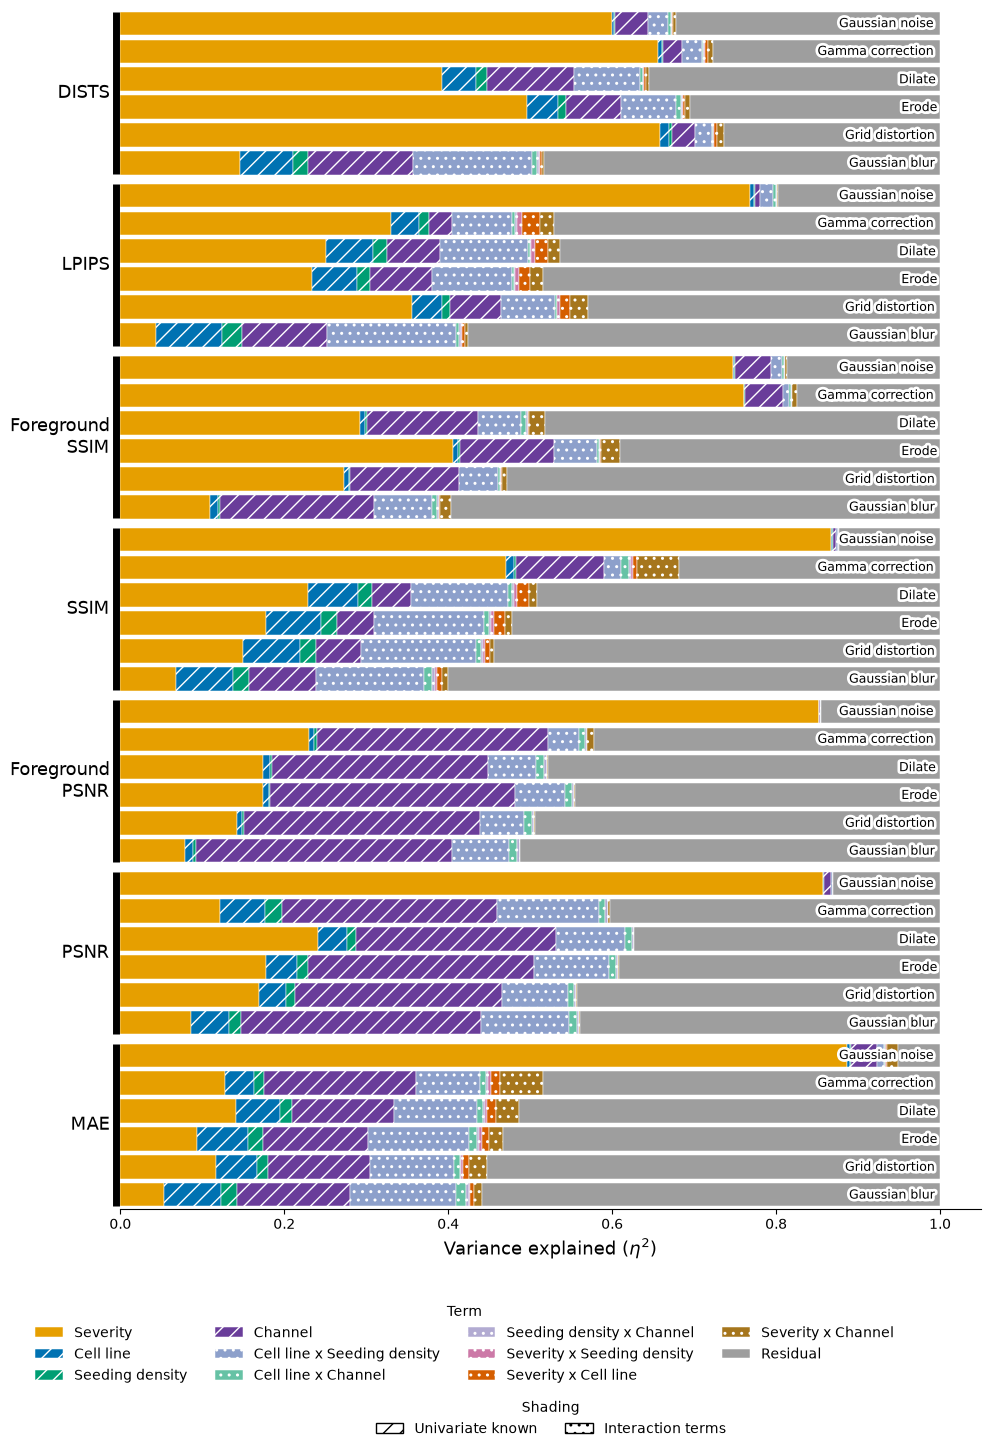

In [6]:
fig, ax, plot_wide = plot_anova_variance_partition(
    variance_partition_df,
    row_cols=(
        "metric_name",
        "transform_name",
    ),
    value_col="eta2",
    term_labels=TERM_LABELS,
    term_order=TERM_ORDER,
    term_colors=TERM_COLORS,
    hatch_groups=HATCH_GROUPS,
    row_orders={
        "metric_name": METRIC_ORDER,
        "transform_name": TRANSFORM_ORDER,
    },
    row_value_labels={
        "metric_name": {
            **METRIC_LABELS,
            "foreground_ssim": "Foreground\nSSIM",
            "foreground_psnr": "Foreground\nPSNR",
        },
        "transform_name": {k: v.replace("\n", " ") for k, v in TRANSFORM_LABELS.items()},
    },
    row_group_col="metric_name",
    row_group_colors={key: "#000000" for key in METRIC_PALETTE},
    row_group_label_x=-0.0125,
    row_group_line_x=-0.005,
    row_group_label_fontsize=13,
    row_group_linewidth=5,
    row_group_line_gap=0.05,
    row_group_gap=0.18,
    row_labels_side="inside",
    row_label_x=0.95,
    row_label_color="black",
    row_label_fontsize=9,
    row_label_outline_width=4,
    show_y_axis=False,
    xlabel_fontsize=13,
    ylabel="",
    output_path=plot_dir / "anova.png",
    figsize_width=10,
    row_height=0.34,
    show=True,
)

Saved figure to results/variance_partition_analysis/plots/anova_radar.png


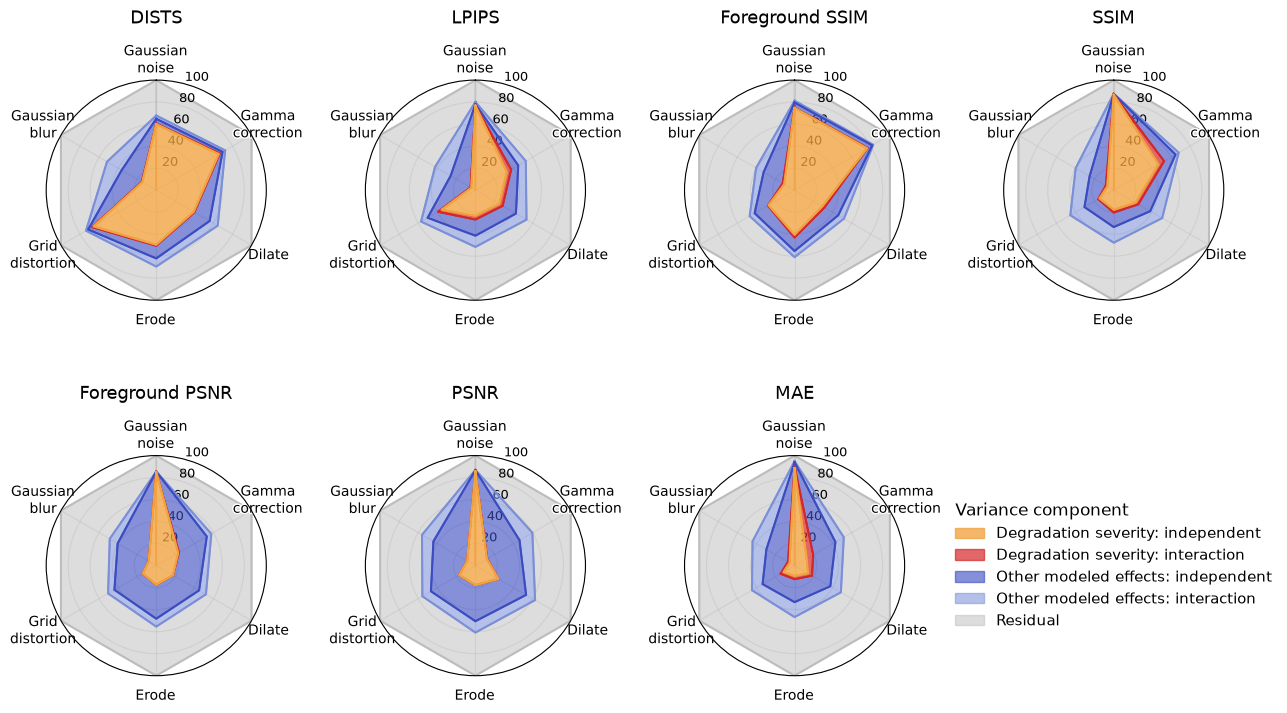

Saved figure to results/variance_partition_analysis/plots/anova_radar_by_degradation.png


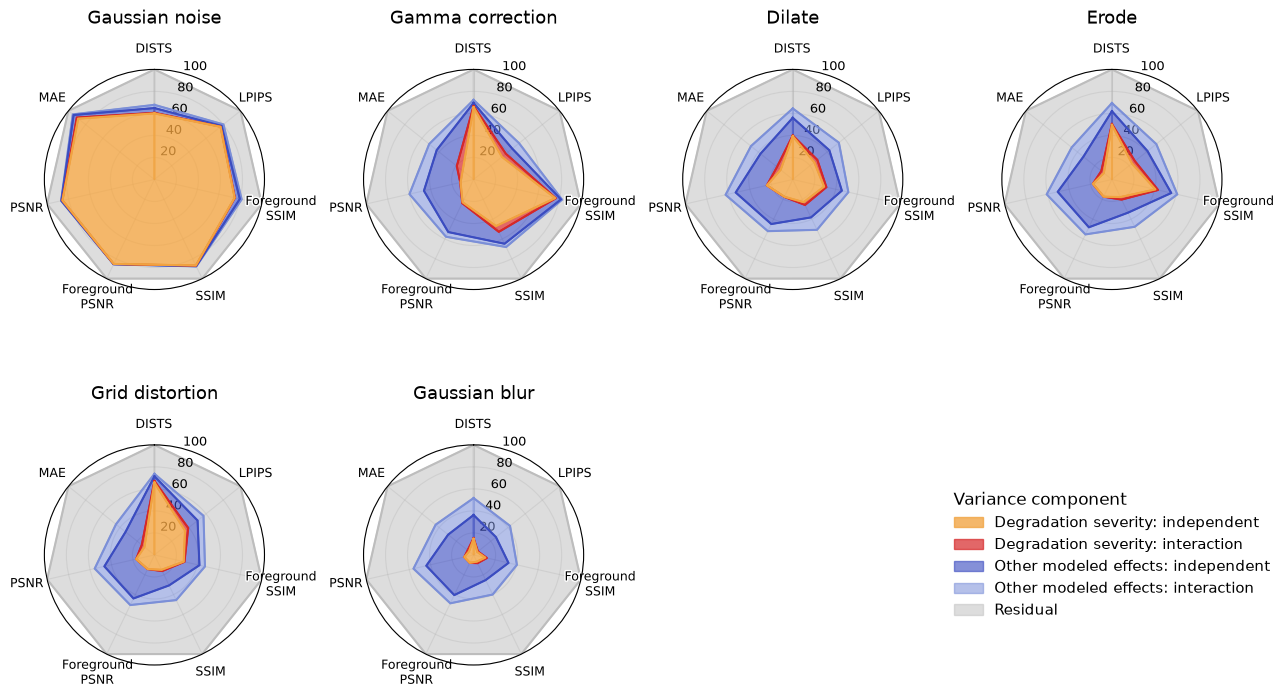

In [7]:
RADAR_COMPONENTS = {
    "severity_independent": {
        "columns": ["parameter_value"],
        "color": "#F1A340",
        "label": "Degradation severity: independent",
        "alpha": 0.78,
    },
    "severity_interaction": {
        "columns": [
            "parameter_value:seeding_density",
            "parameter_value:cell_line",
            "parameter_value:channel",
        ],
        "color": "#D62728",
        "label": "Degradation severity: interaction",
        "alpha": 0.70,
    },
    "other_known_independent": {
        "columns": [
            "cell_line",
            "seeding_density",
            "channel",
        ],
        "color": "#3B4CC0",
        "label": "Other modeled effects: independent",
        "alpha": 0.62,
    },
    "other_known_interaction": {
        "columns": [
            "cell_line:seeding_density",
            "cell_line:channel",
            "seeding_density:channel",
        ],
        "color": "#7B8FD8",
        "label": "Other modeled effects: interaction",
        "alpha": 0.56,
    },
    "residual": {
        "columns": ["Residual"],
        "color": "#BDBDBD",
        "label": "Residual",
        "alpha": 0.50,
    },
}

RADAR_METRIC_LABELS = {
    **METRIC_LABELS,
    "foreground_ssim": "Foreground\nSSIM",
    "foreground_psnr": "Foreground\nPSNR",
}

_ = plot_anova_radar(
    variance_partition_df,
    component_specs=RADAR_COMPONENTS,
    metric_order=METRIC_ORDER,
    metric_labels=RADAR_METRIC_LABELS,
    transform_order=TRANSFORM_ORDER,
    transform_labels=TRANSFORM_LABELS,
    output_path=plot_dir / "anova_radar.png",
    show=True,
)

_ = plot_anova_radar_by_degradation(
    variance_partition_df,
    component_specs=RADAR_COMPONENTS,
    metric_order=METRIC_ORDER,
    metric_labels=RADAR_METRIC_LABELS,
    transform_order=TRANSFORM_ORDER,
    transform_labels=TRANSFORM_LABELS,
    output_path=plot_dir / "anova_radar_by_degradation.png",
    show=True,
)

Saved figure to results/variance_partition_analysis/plots/anova_radar_by_degradation_single_row.png


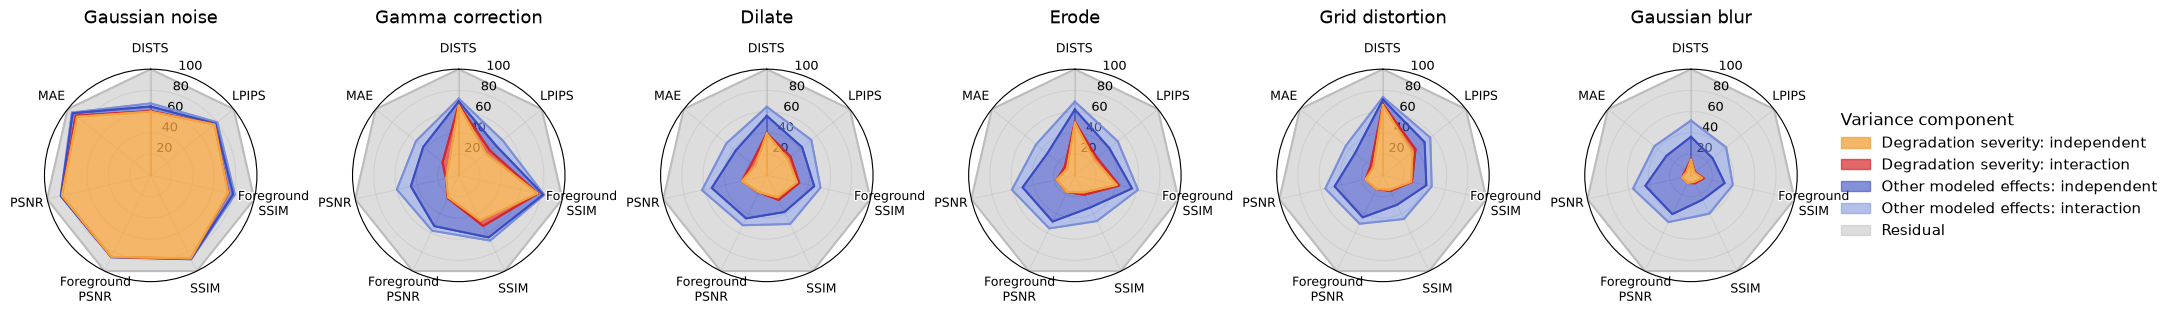

In [8]:
_ = plot_anova_radar_by_degradation(
    variance_partition_df,
    component_specs=RADAR_COMPONENTS,
    metric_order=METRIC_ORDER,
    metric_labels=RADAR_METRIC_LABELS,
    transform_order=TRANSFORM_ORDER,
    transform_labels=TRANSFORM_LABELS,
    layout="single_row",
    output_path=plot_dir / "anova_radar_by_degradation_single_row.png",
    show=True,
)